In [1]:
# --- Step 1: Clean and Install Working RDKit Build ---
!pip install rdkit --quiet
!pip install scikit-learn tqdm joblib --quiet

# Validate RDKit
from rdkit import Chem
from rdkit.Chem import AllChem
print("✅ RDKit imported successfully.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 31.8 MB/s eta 0:00:0000:0100:01m
✅ RDKit imported successfully.


In [2]:
!pip install xgboost --quiet

In [4]:
import pandas as pd
import numpy as np
import random
from tqdm.notebook import tqdm # Use notebook version for Kaggle
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import xgboost as xgb # Import XGBoost
import joblib
import os # For checking file paths
print("Libraries imported.")

Libraries imported.


In [5]:
import pandas as pd
ddi_df = pd.read_feather("/kaggle/input/healthcare-ddi-dfi/ddi_rulesF.feather")
ddi_df.shape

(2855848, 2)

In [6]:
ddi_df.head()

,drug_a_id,drug_b_id
0,DB00001,DB06605
1,DB00001,DB06695
2,DB00001,DB01254
3,DB00001,DB01609
4,DB00001,DB01586


In [7]:
drugs_df = pd.read_csv("/kaggle/input/healthcare-ddi-dfi/drugs.csv")
drugs_df.head()

,drugbank_id,name,synonyms,smiles,atc_code,description,drug_groups,categories,kingdom,superclass,...,subclass,target_ids,enzyme_ids,carrier_ids,transporter_ids,indication,mechanism_of_action,metabolism,toxicity,half_life
0,DB00001,Lepirudin,"[Leu1, Thr2]-63-desulfohirudin; Desulfatohirud...",NaN,B01AE02,Lepirudin is a recombinant hirudin formed by 6...,approved; withdrawn,"Amino Acids, Peptides, and Proteins; Anticoagu...",Organic Compounds,Organic Acids,...,"Amino Acids, Peptides, and Analogues",BE0000048,NaN,NaN,NaN,Lepirudin is indicated for anticoagulation in ...,Lepirudin is a direct thrombin inhibitor used ...,"As a polypeptide, lepirudin is expected to be ...",The acute toxicity of intravenous lepirudin wa...,Lepirudin has an initial half-life of approxim...
1,DB00002,Cetuximab,Cetuximab; Cétuximab; Cetuximabum,NaN,L01FE01,Cetuximab is a recombinant chimeric human/mous...,approved,"Amino Acids, Peptides, and Proteins; Antibodie...",Organic Compounds,Organic Acids,...,"Amino Acids, Peptides, and Analogues",BE0000767; BE0000901; BE0002094; BE0002095; BE...,NaN,NaN,NaN,Cetuximab indicated for the treatment of local...,The epidermal growth factor receptor (EGFR) is...,"Like other monoclonal antibodies, cetuximab is...",The intravenous LD<sub>50</sub> is > 300 mg/kg...,After administration of a 400 mg/m<sup>2</sup>...
2,DB00003,Dornase alfa,Deoxyribonuclease (human clone 18-1 protein mo...,NaN,R05CB13,Dornase alfa is a biosynthetic form of human d...,approved,"Amino Acids, Peptides, and Proteins; Cough and...",Organic Compounds,Organic Acids,...,"Amino Acids, Peptides, and Analogues",BE0012829,NaN,NaN,NaN,Used as adjunct therapy in the treatment of cy...,Dornase alfa is a biosynthetic form of human D...,While no conclusive studies have yet been publ...,Adverse reactions occur at a frequency of < 1/...,NaN
3,DB00004,Denileukin diftitox,DAB(SUB 389)IL2; Denileukin; Denileukin diftit...,NaN,L01XX29,Denileukin diftitox is an IL2-receptor-directe...,approved; investigational,"ADP Ribose Transferases; Amino Acids, Peptides...",Organic Compounds,Organic Acids,...,"Amino Acids, Peptides, and Analogues",BE0000658; BE0000651,NaN,NaN,NaN,Denileukin diftitox was previously indicated f...,Denileukin diftitox is a fusion protein compos...,Denileukin diftitox is expected to be metaboli...,There is limited information regarding the acu...,The arithmetic mean (CV%) denileukin diftitox ...
4,DB00005,Etanercept,Etanercept; etanercept-szzs; etanercept-ykro; ...,NaN,L04AB01,Dimeric fusion protein consisting of the extra...,approved; investigational,"Agents reducing cytokine levels; Amino Acids, ...",Organic Compounds,Organic Acids,...,"Amino Acids, Peptides, and Analogues",BE0000704; BE0001087; BE0000710; BE0002098; BE...,NaN,NaN,NaN,Etanercept is indicated for the treatment of m...,There are two distinct receptors for TNF (TNFR...,"As etanercept is a fusion protein antibody, it...",NaN,Etanercept has a mean half-life of elimination...


In [8]:
drugs_df.shape

(17430, 21)

In [9]:
print("Initial shapes:")
print(f"  Drugs: {drugs_df.shape}")
print(f"  DDIs: {ddi_df.shape}")

Initial shapes:
  Drugs: (17430, 21)
  DDIs: (2855848, 2)


In [10]:
# --- Step 2: Load & Preprocess Datasets ---

import pandas as pd

# Load drug info and DDI rules
#drugs_df = pd.read_csv("drugs.csv")
#ddi_df = pd.read_csv("ddi_rules_clean.csv")

# Keep only drugs with SMILES
usable_drugs = drugs_df[drugs_df['smiles'].notna()][['drugbank_id','smiles']]
usable_drugs.set_index('drugbank_id', inplace=True)

print(f"Total Drugs in Database: {len(drugs_df)}")
print(f"Usable Drugs with SMILES: {len(usable_drugs)} ({len(usable_drugs)/len(drugs_df):.2%})")

# Filter DDIs so both drugs have SMILES
ddi_df = ddi_df[
    ddi_df['drug_a_id'].isin(usable_drugs.index) &
    ddi_df['drug_b_id'].isin(usable_drugs.index)
].drop_duplicates(subset=['drug_a_id', 'drug_b_id'])

print(f"Filtered DDI pairs available for training: {len(ddi_df)}")


Total Drugs in Database: 17430
Usable Drugs with SMILES: 12313 (70.64%)
Filtered DDI pairs available for training: 2323786


In [11]:
# --- Step 3: Generate RDKit Fingerprints ---

from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
from tqdm import tqdm

from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

# Create the generator once
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)

def mol_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((1,))
    Chem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


# Precompute all drug fingerprints
print("Generating molecular fingerprints for usable drugs...")
fingerprints = {}
for dbid, row in tqdm(usable_drugs.iterrows(), total=len(usable_drugs)):
    smiles = row['smiles']
    fp = mol_to_fp(smiles)
    if fp is not None:
        fingerprints[dbid] = fp

print(f"✅ Generated fingerprints for {len(fingerprints)} drugs.")


Generating molecular fingerprints for usable drugs...


 13%|█▎        | 1648/12313 [00:01<00:06, 1768.22it/s][17:07:54] Explicit valence for atom # 13 Cl, 5, is greater than permitted
[17:07:55] SMILES Parse Error: syntax error while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]
[17:07:55] SMILES Parse Error: check for mistakes around position 84:
[17:07:55] C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O
[17:07:55] ~~~~~~~~~~~~~~~~~~~~^
[17:07:55] SMILES Parse Error: extra open parentheses while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]
[17:07:55] SMILES Parse Error: check for mistakes around position 40:
[17:07:55] 1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2
[17:07:55] ~~~~~~~~~~~~~~~~~~~~^
[17:07:55] SMILES Parse Error: extra open parentheses while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\

✅ Generated fingerprints for 12303 drugs.


In [12]:
from tqdm import tqdm
import random

# --- Step 4: Create Training Pairs (Positive + Negative) ---

# (A) Build positive pairs and the positive set
positive_pairs = []
positive_set = set()
for _, row in tqdm(ddi_df.iterrows(), total=len(ddi_df)):
    a, b = row['drug_a_id'], row['drug_b_id']
    if a in fingerprints and b in fingerprints:
        pair = frozenset([a, b])
        if pair not in positive_set:
            positive_set.add(pair)
            positive_pairs.append((a, b, 1))

print(f"✅ Positive pairs collected: {len(positive_pairs)}")

# (B) Build negative pairs (random non-DDIs, not in positive set)
all_ids = list(fingerprints.keys())
negative_pairs = []
negative_needed = len(positive_pairs)

pbar = tqdm(total=negative_needed)
while len(negative_pairs) < negative_needed:
    a, b = random.sample(all_ids, 2)
    pair = frozenset([a, b])
    if pair not in positive_set:
        negative_pairs.append((a, b, 0))
        positive_set.add(pair)  # Prevent reuse as negative
        pbar.update(1)
pbar.close()

print(f"✅ Negative pairs generated: {len(negative_pairs)}")

# (C) Combine and shuffle
dataset = positive_pairs + negative_pairs
random.shuffle(dataset)
print(f"Training dataset size: {len(dataset)} (Positives: {len(positive_pairs)}, Negatives: {len(negative_pairs)})")


100%|██████████| 2323786/2323786 [02:28<00:00, 15634.64it/s]


✅ Positive pairs collected: 1161857


100%|██████████| 1161857/1161857 [00:08<00:00, 141768.43it/s]


✅ Negative pairs generated: 1161857
Training dataset size: 2323714 (Positives: 1161857, Negatives: 1161857)


In [13]:
print(f"Dataset size: {len(dataset)}")

Dataset size: 2323714


In [14]:
# --- Step 4.5: Sample Data  ---
N = 500000  # Adjust based on available RAM/time (e.g., 500k, 1M)
if len(dataset) > N:
    print(f"\nSampling {N} pairs from the full dataset for training/testing...")
    dataset = random.sample(dataset, N)
else:
    print(f"\nUsing full dataset of {len(dataset)} pairs for training/testing.")


Sampling 500000 pairs from the full dataset for training/testing...


In [15]:
    
# --- Step 5: Feature Vector Construction ---

X, y = [], []
for a, b, label in tqdm(dataset):
    fp_a, fp_b = fingerprints[a], fingerprints[b]
    combined = np.concatenate([fp_a, fp_b])  # simple concatenation
    X.append(combined)
    y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y)
print(f"Feature matrix shape: {X.shape}")


100%|██████████| 500000/500000 [00:22<00:00, 21772.65it/s]


Feature matrix shape: (500000, 4096)


In [16]:
# --- Step 5: Feature Vector Construction ---
print("\n--- Constructing Feature Vectors ---")
X, y = [], []
for a, b, label in tqdm(dataset, desc="Building X, y"):
    fp_a = fingerprints.get(a)
    fp_b = fingerprints.get(b)
    # Ensure both fingerprints were successfully generated
    if fp_a is not None and fp_b is not None:
        # Simple concatenation
        combined = np.concatenate([fp_a, fp_b])
        X.append(combined)
        y.append(label)

X = np.array(X, dtype=np.float32) # XGBoost prefers float32
y = np.array(y)

print(f"Feature matrix X shape: {X.shape}")
print(f"Label vector y shape: {y.shape}")


--- Constructing Feature Vectors ---


Building X, y: 100%|██████████| 500000/500000 [00:06<00:00, 81783.64it/s]


Feature matrix X shape: (500000, 4096)
Label vector y shape: (500000,)


In [17]:
# --- Step 6: Train XGBoost Model ---
print("\n--- Training XGBoost Model ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Stratify preserves class balance

print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Define XGBoost model - parameters can be tuned
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic', # for binary classification
    n_estimators=200,          # Number of trees (like RF)
    learning_rate=0.1,         # How much each tree corrects the previous ones
    max_depth=7,               # Max depth of trees (shallower than RF often works well)
    subsample=0.8,             # Fraction of samples used per tree
    colsample_bytree=0.8,      # Fraction of features used per tree
    use_label_encoder=False,   # Recommended setting
    eval_metric='logloss',     # Metric for evaluation during training
    random_state=42,
    n_jobs=-1                  # Use all available CPU cores
)

print("Fitting XGBoost model...")
# Optional: Add early stopping
# eval_set = [(X_test, y_test)]
# xgb_model.fit(X_train, y_train, early_stopping_rounds=10, eval_set=eval_set, verbose=True)
xgb_model.fit(X_train, y_train,verbose=True) # Train without early stopping for simplicity


--- Training XGBoost Model ---
Train set size: 400000
Test set size: 100000
Fitting XGBoost model...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [18]:
# --- Step 7: Evaluate XGBoost Model ---
print("\n--- Evaluating Model ---")
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))


--- Evaluating Model ---
XGBoost Model Performance:
  Accuracy: 0.8890
  ROC AUC: 0.9544

Classification report:
               precision    recall  f1-score   support

           0     0.9193    0.8530    0.8849     50026
           1     0.8627    0.9251    0.8928     49974

    accuracy                         0.8890    100000
   macro avg     0.8910    0.8890    0.8889    100000
weighted avg     0.8910    0.8890    0.8889    100000



In [19]:
# --- Step 8: Save Trained XGBoost Model ---
model_filename = "ddi_xgb_model.pkl"
joblib.dump(xgb_model, model_filename)
print(f"\nXGBoost model saved as '{model_filename}'")


XGBoost model saved as 'ddi_xgb_model.pkl'


In [20]:
# --- Step 9: Example Prediction Function (using XGBoost) ---
print("\n--- Testing Prediction Function ---")
loaded_xgb_model = joblib.load(model_filename) # Load the saved model

def predict_interaction_xgb(smiles_a, smiles_b, model, fp_dict):
    """Predicts DDI probability using SMILES, a loaded model, and precomputed fps."""
    # Find precomputed fingerprints using DrugBank IDs (Requires mapping smiles back to ID or passing IDs)
    # --- This part needs adjustment based on how you want to call it ---
    # Simplified version assuming SMILES are directly mappable or IDs are passed
    # For now, we'll recompute FP for the example, but using the dict is faster
    fpA = mol_to_fp(smiles_a)
    fpB = mol_to_fp(smiles_b)

    if fpA is None or fpB is None:
        return "Invalid SMILES input or fingerprint generation failed."

    features = np.concatenate([fpA, fpB]).reshape(1, -1).astype(np.float32)
    prob = model.predict_proba(features)[0][1] # Probability of class 1 (interaction)
    risk = "High" if prob >= 0.75 else "Moderate" if prob >= 0.5 else "Low"
    return f"Predicted Interaction Probability: {prob:.3f}, Risk Level: {risk}"

# Example test case: Warfarin & Simvastatin (Need SMILES strings)
# You need to fetch these SMILES from your usable_drugs DataFrame or fingerprints dict
try:
    warfarin_smiles = usable_drugs.loc["DB00682", "smiles"]
    simvastatin_smiles = usable_drugs.loc["DB00641", "smiles"] # Ensure this ID is correct in your data
    print("\nPredicting Warfarin + Simvastatin:")
    print(predict_interaction_xgb(warfarin_smiles, simvastatin_smiles, loaded_xgb_model, fingerprints))
except KeyError as e:
    print(f"\nCould not run example prediction: Drug ID {e} not found in usable_drugs index.")

print("\nScript finished.")


--- Testing Prediction Function ---

Predicting Warfarin + Simvastatin:
Predicted Interaction Probability: 0.746, Risk Level: Moderate

Script finished.


In [22]:
# Add this cell if you haven't installed them
!pip install matplotlib seaborn --quiet


--- Generating Visualizations ---
Plotting Confusion Matrix...


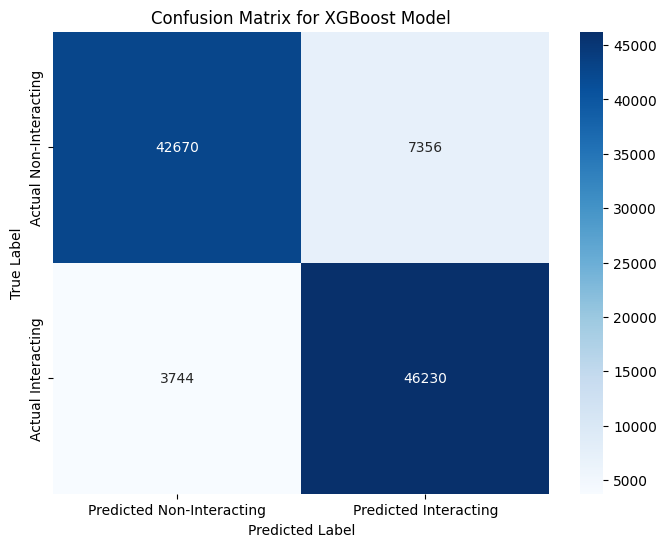

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np

print("\n--- Generating Visualizations ---")

# --- 1. Confusion Matrix ---
print("Plotting Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Interacting', 'Predicted Interacting'],
            yticklabels=['Actual Non-Interacting', 'Actual Interacting'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for XGBoost Model')
plt.show()



Plotting ROC Curve...


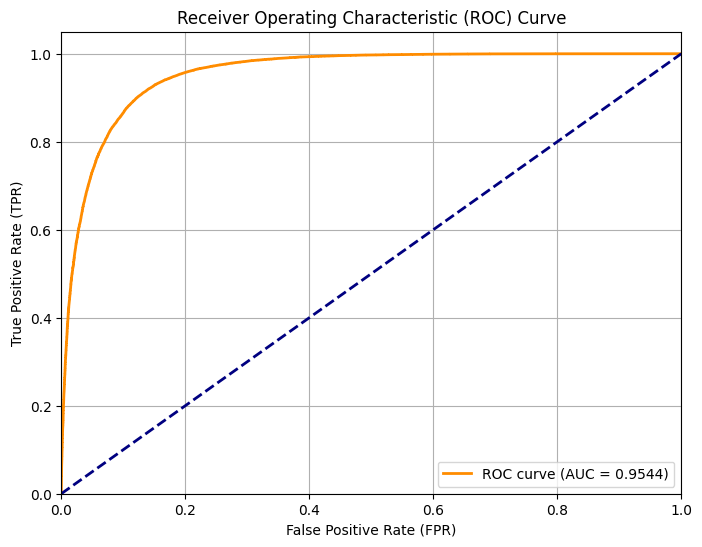

Area Under ROC Curve (AUC): 0.9544


In [25]:

# --- 2. ROC Curve ---
print("\nPlotting ROC Curve...")
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal line for random guess
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
print(f"Area Under ROC Curve (AUC): {roc_auc:.4f}")


Plotting Precision-Recall Curve...


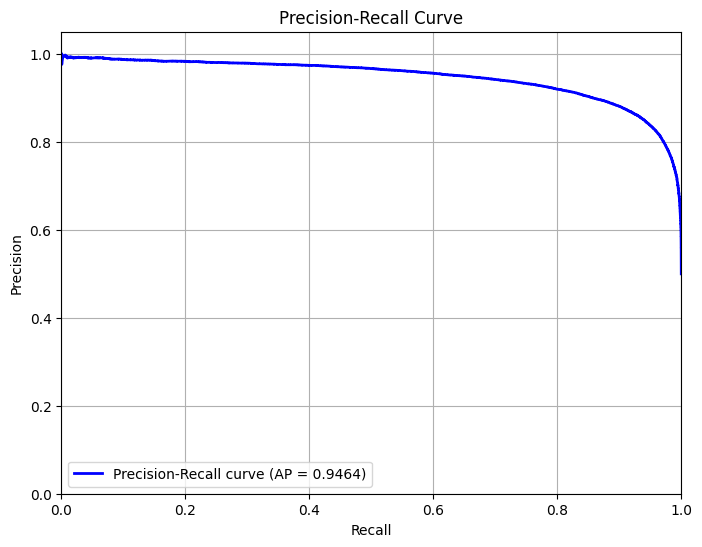

Average Precision (AP): 0.9464


In [26]:

# --- 3. Precision-Recall Curve ---
print("\nPlotting Precision-Recall Curve...")
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (AP = {avg_precision:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()
print(f"Average Precision (AP): {avg_precision:.4f}")


Calculating and Plotting Feature Importance (Top 15)...


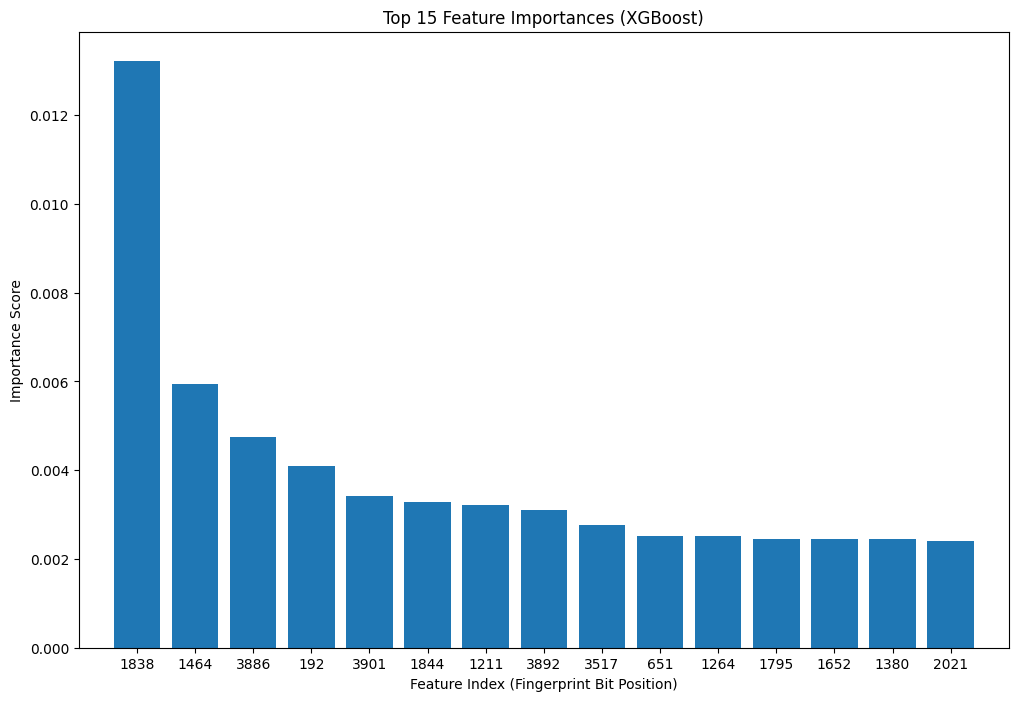


Top 10 Feature Indices and Importances:
1. Feature Index: 1838, Importance: 0.0132
2. Feature Index: 1464, Importance: 0.0059
3. Feature Index: 3886, Importance: 0.0047
4. Feature Index: 192, Importance: 0.0041
5. Feature Index: 3901, Importance: 0.0034
6. Feature Index: 1844, Importance: 0.0033
7. Feature Index: 1211, Importance: 0.0032
8. Feature Index: 3892, Importance: 0.0031
9. Feature Index: 3517, Importance: 0.0028
10. Feature Index: 651, Importance: 0.0025

Visualizations complete.


In [28]:
# --- 4. Feature Importance ---
# NOTE: This can be slow and memory-intensive if run directly on 4096 features.
# It might be better to show only the top N features.
print("\nCalculating and Plotting Feature Importance (Top 15)...")
try:
    importances = xgb_model.feature_importances_
    indices = np.argsort(importances)[::-1] # Get indices sorted by importance (descending)
    top_n = 15 # Number of top features to plot

    plt.figure(figsize=(12, 8))
    plt.title(f"Top {top_n} Feature Importances (XGBoost)")
    plt.bar(range(top_n), importances[indices[:top_n]], align='center')
    # Feature names here are just bit indices (0 to 4095)
    plt.xticks(range(top_n), indices[:top_n])
    plt.xlim([-1, top_n])
    plt.xlabel("Feature Index (Fingerprint Bit Position)")
    plt.ylabel("Importance Score")
    plt.show()

    print("\nTop 10 Feature Indices and Importances:")
    for i in range(10):
        print(f"{i+1}. Feature Index: {indices[i]}, Importance: {importances[indices[i]]:.4f}")

except Exception as e:
    print(f"Could not plot feature importances: {e}")
    print("(This might happen if the model wasn't fitted or feature names are unexpected)")

print("\nVisualizations complete.")


--- Generating Additional Visualizations ---

Plotting Calibration Curve...


/usr/local/lib/python3.11/dist-packages/sklearn/calibration.py:1176: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  self.line_ = ax.plot(self.prob_pred, self.prob_true, "s-", **line_kwargs)[0]
/usr/local/lib/python3.11/dist-packages/sklearn/calibration.py:1176: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "s-" (-> marker='s'). The keyword argument will take precedence.
  self.line_ = ax.plot(self.prob_pred, self.prob_true, "s-", **line_kwargs)[0]


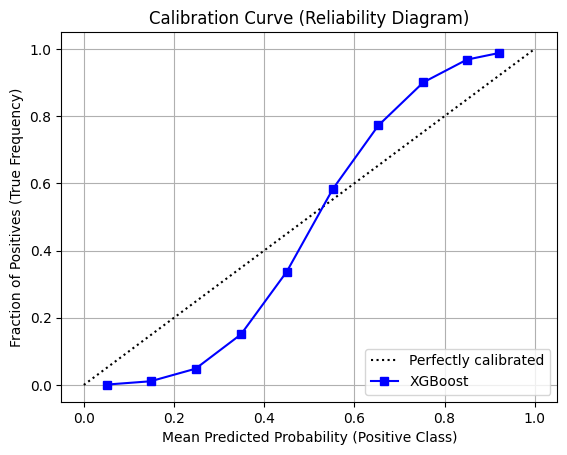

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import calibration_curve, CalibrationDisplay

print("\n--- Generating Additional Visualizations ---")

# --- 5. Calibration Curve ---
# Shows how well the predicted probabilities align with the actual frequencies.
# A perfectly calibrated model follows the diagonal line.
print("\nPlotting Calibration Curve...")

# Calculate calibration curve data
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='uniform')

# Plot using CalibrationDisplay for better formatting
disp = CalibrationDisplay(prob_true, prob_pred, y_prob)
disp.plot(name='XGBoost', marker='s', linestyle='-', color='blue')

plt.title('Calibration Curve (Reliability Diagram)')
plt.xlabel('Mean Predicted Probability (Positive Class)')
plt.ylabel('Fraction of Positives (True Frequency)')
plt.grid(True)
plt.show()


Plotting Distribution of Predicted Probabilities...


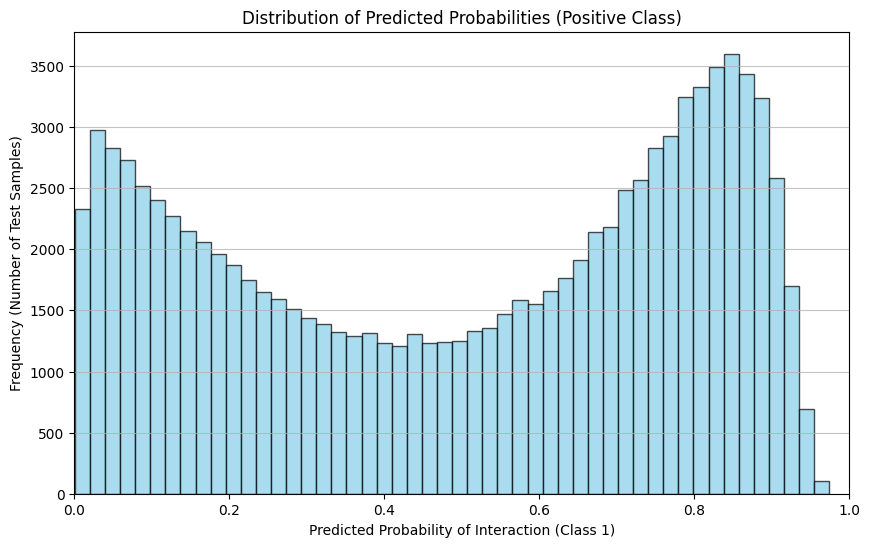


Additional visualizations complete.


In [31]:


# --- 6. Distribution of Predicted Probabilities ---
# Shows how confident the model is in its predictions.
# Ideally, for a good binary classifier, probabilities should cluster near 0 and 1.
print("\nPlotting Distribution of Predicted Probabilities...")

plt.figure(figsize=(10, 6))
# Plot histogram of predicted probabilities for the positive class (class 1)
plt.hist(y_prob, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlim(0, 1) # Probabilities range from 0 to 1
plt.title('Distribution of Predicted Probabilities (Positive Class)')
plt.xlabel('Predicted Probability of Interaction (Class 1)')
plt.ylabel('Frequency (Number of Test Samples)')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("\nAdditional visualizations complete.")